# Plots to differentiate models

Conda environment for this notebook

´´´
conda env create
´´´

## Plots of training sequences


MNIST_HGQ_DynamicTraining_log
merk at accuracy kollapser rundt epoch 4250

In [2]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import pandas as pd
import numpy as np
%matplotlib inline

In [3]:
datadir = "../Modeller/model_HGQ"

nrows, ncols = 2, 3

colors = [ "#3e6990", "#aabd8c", "#e9e3b4", "#f39b6d","#381d2a",]

config = [
    {"labelname": "MNIST_HGQ_DynamicTraining", "filename": "MNIST_HGQ_DynamicTraining_log.csv"},
    {"labelname": "MNIST_HGQ_StaticTraining", "filename": "MNIST_HGQ_StaticTraining_log.csv"},
    {"labelname": "MNIST_MLP_HGQ_StaticTraining", "filename": "MNIST_MLP_HGQ_StaticTraining_log.csv"},
    {"labelname": "MNIST_MLP_HQG_DynamicTraining", "filename": "MNIST_MLP_HQG_DynamicTraining_log.csv"},
    {"labelname": "JET_HGQ_Training", "filename": "JET_HGQ_Training_log.csv"},
]

data = [
    {
        "labelname": line["labelname"],
        "filename": f"{datadir}/{line['filename']}",
        "dataframe": pd.read_csv(f"{datadir}/{line['filename']}", sep=';', index_col=0),
    }
    for line in config
]

data[0]
#df = data[1]["dataframe"]
#df[:10]

{'labelname': 'MNIST_HGQ_DynamicTraining',
 'filename': '../Modeller/model_HGQ/MNIST_HGQ_DynamicTraining_log.csv',
 'dataframe':        accuracy          beta     ebops  learning_rate      loss  \
 epoch                                                              
 0      0.142537  1.000000e-07  32608422       0.000100  5.546310   
 1      0.237685  1.000000e-07  32608422       0.000118  5.445072   
 2      0.360463  1.000000e-07  32608422       0.000136  5.306185   
 3      0.464556  1.000000e-07  32608422       0.000154  5.104195   
 4      0.543907  1.000000e-07  32608422       0.000172  4.844032   
 ...         ...           ...       ...            ...       ...   
 4352   0.105278  1.863803e-05      9313       0.000160  2.585961   
 4353   0.106759  1.864661e-05      9311       0.000160  2.609967   
 4354   0.105704  1.865520e-05      9301       0.000159  2.592675   
 4355   0.106037  1.866380e-05      9287       0.000159  2.598967   
 4356   0.104852  1.867239e-05      9273    

### Accuracy over Ebops

5
overflow 4


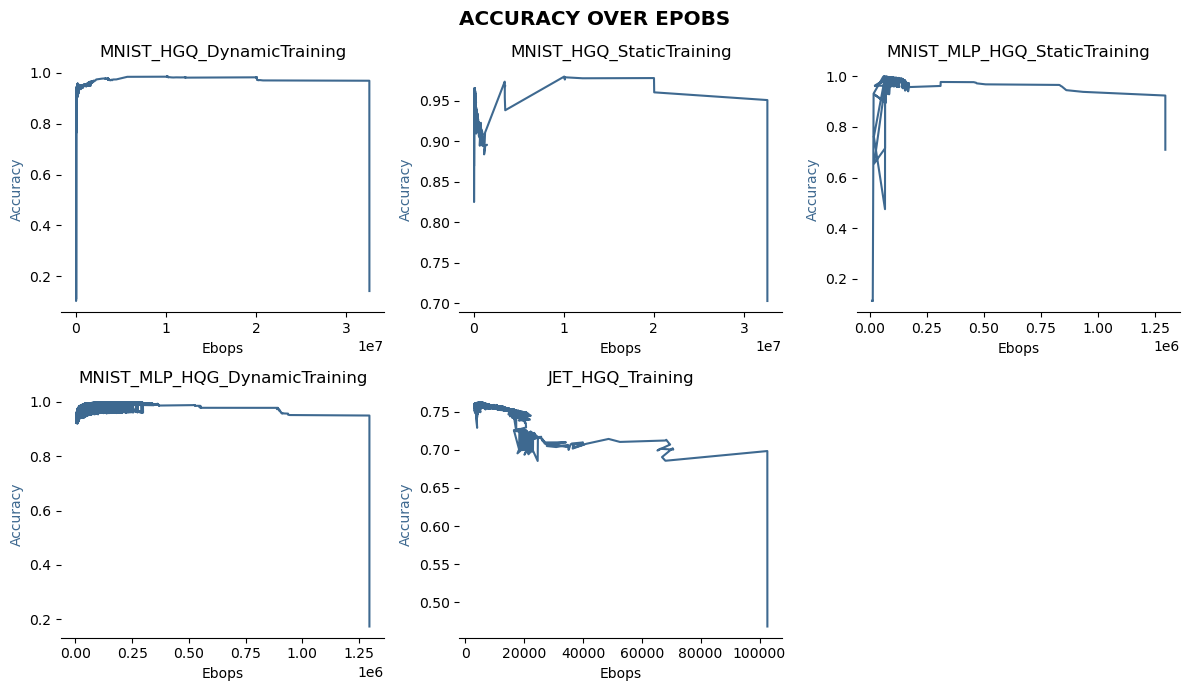

In [26]:
plotname = "Accuracy over Epobs"
fig, axs = plt.subplots(nrows=nrows, ncols=ncols,figsize=(12, 7))
axs = axs.flatten()
print(len(data))

for i, item in enumerate(data):
    #ax = axs[i // 3, i % 3] # flattened instead
    ax1 = axs[i]
    df = item['dataframe']
    ax1.set_title(item['labelname'])
    ax1.set_xlabel('Ebops')
    ax1.set_ylabel('Accuracy', color=colors[0])
    ax1.plot('ebops', 'accuracy', data=df, color=colors[0])
    # Overflow
    if (i+1) >= len(data):
        axs[i+1].axis('off')
        print("overflow", i)

    ax1.spines["right"].set_visible(False)
    ax1.spines["left"].set_visible(False)
    ax1.spines["top"].set_visible(False)

plt.suptitle(plotname.upper(), size = 'x-large', weight = 'bold')
plt.tight_layout()
plt.show()
fig.savefig(f"export/{plotname.lower()}.png", dpi=300, bbox_inches="tight")

### Accuracy and Ebops over Epochs (timeseries)

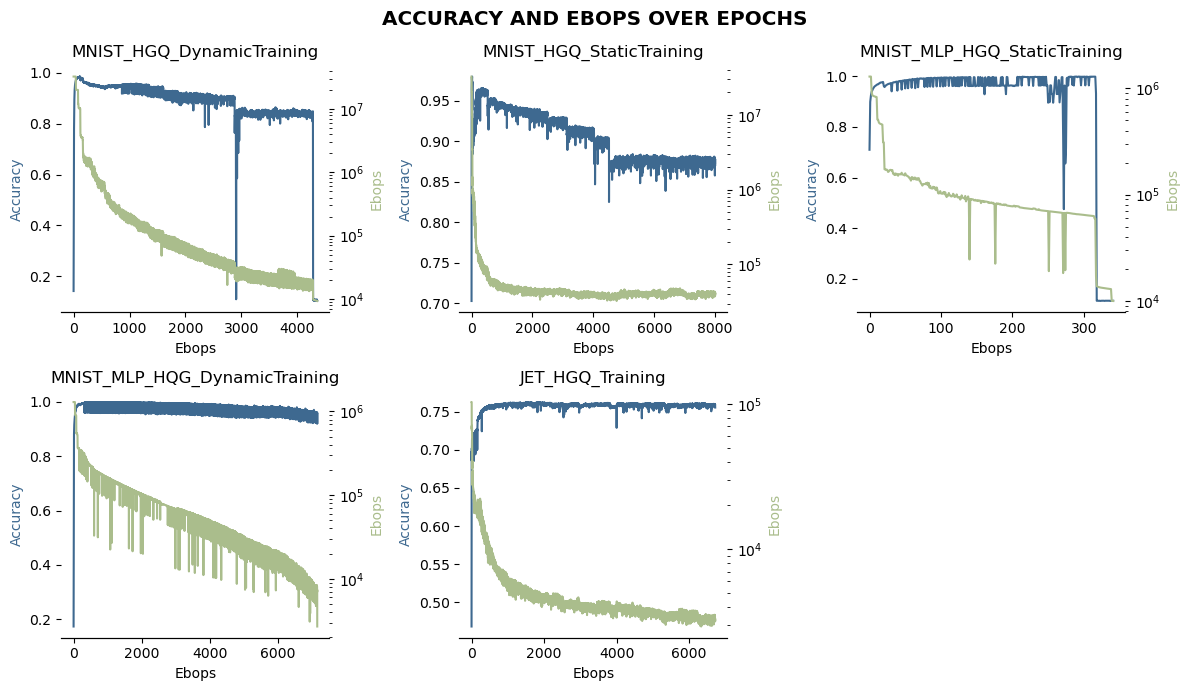

In [ ]:
plotname = "Accuracy and Ebops over Epochs"
fig, axs = plt.subplots(nrows=nrows, ncols=ncols,figsize=(12, 7))
axs = axs.flatten()


for i, item in enumerate(data):
    ax1 = axs[i]
    ax2 = ax1.twinx()
    df = item['dataframe']

    ax1.set_title(item['labelname'])
    ax1.set_xlabel('Ebops')
    ax1.set_ylabel('Accuracy', color=colors[0])
    ax1.plot(df.index, 'accuracy', data=df, color=colors[0])

    ax2.set_ylabel('Ebops', color=colors[1])
    ax2.semilogy(df.index, 'ebops', data=df, color=colors[1])
    # Overflow
    if (i+1) >= len(data):
        axs[i+1].axis('off')

    ax1.spines["right"].set_visible(False)
    ax1.spines["left"].set_visible(False)
    ax1.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.spines["left"].set_visible(False)
    ax2.spines["top"].set_visible(False)
    #ax2.grid()

    
plt.suptitle(plotname.upper(), size = 'x-large', weight = 'bold')
plt.tight_layout()
plt.show()
fig.savefig(f"export/{plotname.lower()}.png", dpi=300, bbox_inches="tight")


# Annotations https://matplotlib.org/stable/gallery/text_labels_and_annotations/annotate_transform.html
# Minimalistic https://practicaldatascience.org/notebooks/class_5/week_1/2.2.2_making_plots_pretty_2.html